# comparison between BCE and CE loss

Model A --> CrossEntropyLoss

Model B --> BCEWithLogitsLoss

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import random
import numpy as np

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

print("Seed:", seed)

Seed: 42


In [3]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


In [4]:
train_dataset = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)
val_dataset = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# Model A --> CrossEntropyLoss

In [5]:
class CELossCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
            )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56,num_classes)
            )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_ce = CELossCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_ce.parameters(),
    lr=0.001
)

In [7]:
num_epochs = 10

best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training
    model_ce.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_ce(images)

        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss =running_train_loss /len(train_loader)

    # Validation
    model_ce.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_ce(images)
            loss = criterion(outputs,labels)
            
            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = running_val_loss /len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_ce.state_dict(),
            "best_ce_model.pt"
        )
        print(" --> Best CE model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:",best_val_accuracy)

 --> Best CE model saved!
Epoch [1/10] Train Loss: 1.7990 Val Loss: 0.9355 Val Accuracy: 0.7145
 --> Best CE model saved!
Epoch [2/10] Train Loss: 0.6582 Val Loss: 0.7668 Val Accuracy: 0.7558
 --> Best CE model saved!
Epoch [3/10] Train Loss: 0.4267 Val Loss: 0.6459 Val Accuracy: 0.7855
 --> Best CE model saved!
Epoch [4/10] Train Loss: 0.3092 Val Loss: 0.6259 Val Accuracy: 0.7984
Epoch [5/10] Train Loss: 0.1841 Val Loss: 0.6821 Val Accuracy: 0.7868
 --> Best CE model saved!
Epoch [6/10] Train Loss: 0.0969 Val Loss: 0.8742 Val Accuracy: 0.8152
Epoch [7/10] Train Loss: 0.0841 Val Loss: 0.7510 Val Accuracy: 0.7984
Epoch [8/10] Train Loss: 0.0672 Val Loss: 0.8899 Val Accuracy: 0.7933
Epoch [9/10] Train Loss: 0.0581 Val Loss: 0.8798 Val Accuracy: 0.8075
 --> Best CE model saved!
Epoch [10/10] Train Loss: 0.0283 Val Loss: 0.8521 Val Accuracy: 0.8191


Best Epoch: 10
Best Validation Accuracy: 0.8191214470284238


## Evaluate Best CE Model

In [ ]:
model_ce.load_state_dict(
    torch.load("best_ce_model.pt", map_location="cpu")
)
best_ce_model = model_ce.to(device)
best_ce_model.eval()
all_labels_CE = []
all_predictions_CE = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_ce_model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels_CE.extend(labels.cpu().numpy())
        all_predictions_CE.extend(predictions.cpu().numpy())

print("Predictions:", len(all_predictions_CE))
print("Labels:", len(all_labels_CE))

# ==============================================

accuracy = accuracy_score(all_labels_CE, all_predictions_CE)
precision = precision_score(all_labels_CE, all_predictions_CE, average="macro", zero_division=0)
recall = recall_score(all_labels_CE, all_predictions_CE, average="macro", zero_division=0)
f1 = f1_score(all_labels_CE, all_predictions_CE, average="macro", zero_division=0)
cm = confusion_matrix(all_labels_CE, all_predictions_CE, labels=list(range(len(classes))))

print("="*40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("Confusion Matrix:\n",cm)

report = classification_report(all_labels_CE, all_predictions_CE, labels=list(range(len(classes))),
                            target_names=classes, zero_division=0)
print("\nClassification Report:\n",report)

Predictions: 774
Labels: 774
Accuracy : 0.8191
Precision: 0.8217
Recall   : 0.8138
F1 Score : 0.8161
Confusion Matrix:
 [[ 56   0   8   2   4   0   2]
 [  2  72  13   1   2   2   1]
 [ 13   7 154   8   1   1   5]
 [  3   1  16  58   0   0   0]
 [  5   0   3   0  80   2  10]
 [  1   1   2   1   1  91   0]
 [  5   1   3   0  13   0 123]]

Classification Report:
               precision    recall  f1-score   support

   ambulance       0.66      0.78      0.71        72
     autobus       0.88      0.77      0.82        93
      kamyun       0.77      0.81      0.79       189
     minibus       0.83      0.74      0.78        78
      savari       0.79      0.80      0.80       100
        taxi       0.95      0.94      0.94        97
       vanet       0.87      0.85      0.86       145

    accuracy                           0.82       774
   macro avg       0.82      0.81      0.82       774
weighted avg       0.82      0.82      0.82       774



# Model B --> BCEWithLogitsLoss

In [8]:
class BCELossCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_BCE = BCELossCNN(num_classes=len(classes)).to(device)

criterion_bce = nn.BCEWithLogitsLoss()

optimizer_bce = torch.optim.Adam(
    model_BCE.parameters(),
    lr=0.001
)

In [10]:
num_epochs = 10
best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    model_BCE.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_bce.zero_grad()
        outputs = model_BCE(images)

        # Convert labels to one-hot
        labels_one_hot = torch.zeros(labels.size(0),len(classes)).to(device)
        labels_one_hot.scatter_(1,labels.unsqueeze(1),1)

        loss = criterion_bce(outputs,labels_one_hot)
        loss.backward()
        optimizer_bce.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # Validation
    model_BCE.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_BCE(images)

            # One-hot labels
            labels_one_hot = torch.zeros(labels.size(0),len(classes)).to(device)
            labels_one_hot.scatter_(1,labels.unsqueeze(1),1)

            loss = criterion_bce(outputs,labels_one_hot)
            running_val_loss  += loss.item()

            # BCE -> sigmoid -> class prediction
            probabilities = torch.sigmoid(outputs)
            predicted = torch.argmax(probabilities,dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_BCE.state_dict(),
            "best_bce_model.pt"
        )
        print(" --> Best BCE model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
        )

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:",best_val_accuracy)

 --> Best BCE model saved!
Epoch [1/10] Train Loss: 0.3840 Val Loss: 0.2165 Val Accuracy: 0.7196
 --> Best BCE model saved!
Epoch [2/10] Train Loss: 0.1488 Val Loss: 0.1627 Val Accuracy: 0.8049
 --> Best BCE model saved!
Epoch [3/10] Train Loss: 0.0838 Val Loss: 0.1480 Val Accuracy: 0.8152
Epoch [4/10] Train Loss: 0.0400 Val Loss: 0.1787 Val Accuracy: 0.8010
 --> Best BCE model saved!
Epoch [5/10] Train Loss: 0.0222 Val Loss: 0.1862 Val Accuracy: 0.8333
Epoch [6/10] Train Loss: 0.0139 Val Loss: 0.1944 Val Accuracy: 0.8320
Epoch [7/10] Train Loss: 0.0064 Val Loss: 0.2213 Val Accuracy: 0.8320
 --> Best BCE model saved!
Epoch [8/10] Train Loss: 0.0028 Val Loss: 0.2257 Val Accuracy: 0.8540
Epoch [9/10] Train Loss: 0.0034 Val Loss: 0.2426 Val Accuracy: 0.8450
Epoch [10/10] Train Loss: 0.0045 Val Loss: 0.2687 Val Accuracy: 0.8320


Best Epoch: 8
Best Validation Accuracy: 0.8540051679586563


## Evaluate Best BCE Model

In [15]:
model_BCE.load_state_dict(
    torch.load("best_bce_model.pt", map_location="cpu")
)
best_bce_model = model_BCE.to(device)
best_bce_model.eval()
all_labels_BCE = []
all_predictions_BCE = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_bce_model(images)
        probabilities = torch.sigmoid(outputs)
        predictions = torch.argmax(probabilities, dim=1)

        all_labels_BCE.extend(labels.cpu().numpy())
        all_predictions_BCE.extend(predictions.cpu().numpy())

print("Predictions:", len(all_predictions_BCE))
print("Labels:", len(all_labels_BCE))

# ==============================================

accuracy = accuracy_score(all_labels_BCE, all_predictions_BCE)
precision = precision_score(all_labels_BCE, all_predictions_BCE, average="macro", zero_division=0)
recall = recall_score(all_labels_BCE, all_predictions_BCE, average="macro", zero_division=0)
f1 = f1_score(all_labels_BCE, all_predictions_BCE, average="macro", zero_division=0)
cm = confusion_matrix(all_labels_BCE, all_predictions_BCE, labels=list(range(len(classes))))

print("="*40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("Confusion Matrix:\n", cm)

report_BCE = classification_report(all_labels_BCE, all_predictions_BCE, labels=list(range(len(classes))),
                               target_names=classes, zero_division=0)
print("\nClassification Report:\n", report_BCE)

Predictions: 774
Labels: 774
Accuracy : 0.8540
Precision: 0.8592
Recall   : 0.8507
F1 Score : 0.8538
Confusion Matrix:
 [[ 55   1  10   2   2   0   2]
 [  1  73  12   3   1   1   2]
 [ 10   2 158   8   1   2   8]
 [  0   0  10  67   0   1   0]
 [  2   1   4   0  89   1   3]
 [  1   1   0   0   3  91   1]
 [  2   0   5   1   8   1 128]]

Classification Report:
               precision    recall  f1-score   support

   ambulance       0.77      0.76      0.77        72
     autobus       0.94      0.78      0.85        93
      kamyun       0.79      0.84      0.81       189
     minibus       0.83      0.86      0.84        78
      savari       0.86      0.89      0.87       100
        taxi       0.94      0.94      0.94        97
       vanet       0.89      0.88      0.89       145

    accuracy                           0.85       774
   macro avg       0.86      0.85      0.85       774
weighted avg       0.86      0.85      0.85       774



## CE vs BCE

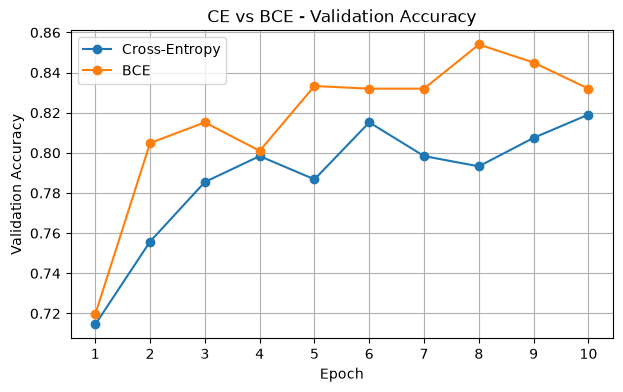

In [18]:
epochs = range(1, 11)
ce_val_accuracy = [
    0.7145,
    0.7558,
    0.7855,
    0.7984,
    0.7868,
    0.8152,
    0.7984,
    0.7933,
    0.8075,
    0.8191
]
bce_val_accuracy = [
    0.7196,
    0.8049,
    0.8152,
    0.8010,
    0.8333,
    0.8320,
    0.8320,
    0.8540,
    0.8450,
    0.8320
]
plt.figure(figsize=(7, 4))
plt.plot(epochs, ce_val_accuracy, marker="o", label="Cross-Entropy")
plt.plot(epochs, bce_val_accuracy, marker="o", label="BCE")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("CE vs BCE - Validation Accuracy")

plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()